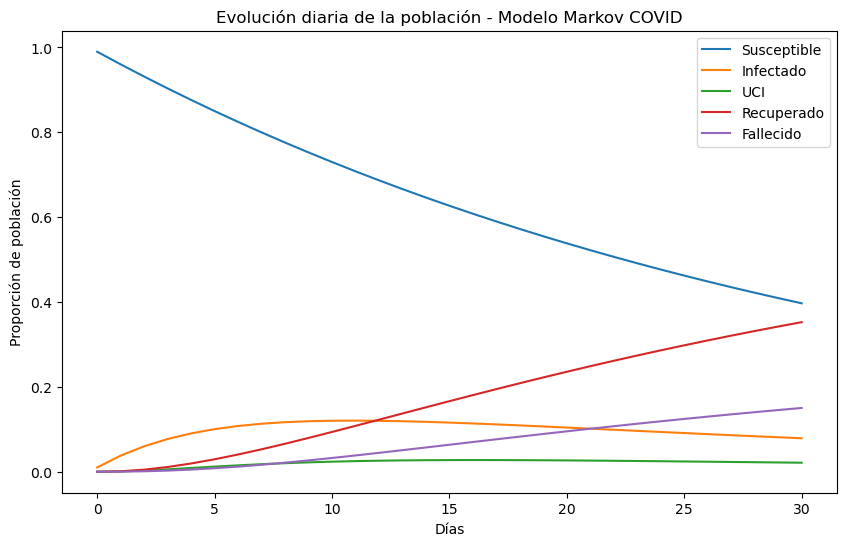

Estado estacionario: [0.  0.  0.  0.  0.  0.  0.  0.5 0.5 0. ]
Probabilidad final de fallecimiento: 0.0
Tiempo medio hasta absorción por estado no absorbente: [40.22222222  6.88888889  4.        ]


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Matriz de transición
P = np.array([
    [0.97, 0.03, 0.00, 0.00, 0.00],  # S
    [0.00, 0.82, 0.06, 0.10, 0.02],  # I
    [0.00, 0.00, 0.75, 0.10, 0.15],  # U
    [0.00, 0.00, 0.00, 1.00, 0.00],  # R
    [0.00, 0.00, 0.00, 0.00, 1.00]   # F
])

# Vector inicial
v0 = np.array([0.99, 0.01, 0.0, 0.0, 0.0])

# Evolución diaria
def evolucion(v0, P, dias):
    historia = [v0]
    v = v0
    for _ in range(dias):
        v = v @ P
        historia.append(v)
    return np.array(historia)

dias = 30
historia = evolucion(v0, P, dias)

# Extraer estados
S, I, U, R, F = historia.T

# -----------------------------
# 3️⃣ Graficar evolución
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(S, label='Susceptible')
plt.plot(I, label='Infectado')
plt.plot(U, label='UCI')
plt.plot(R, label='Recuperado')
plt.plot(F, label='Fallecido')
plt.xlabel('Días')
plt.ylabel('Proporción de población')
plt.title('Evolución diaria de la población - Modelo Markov COVID')
plt.legend()
plt.show()

# -----------------------------
# 4️⃣ Estado estacionario
# -----------------------------
valores, vectores = np.linalg.eig(P.T)
indice = np.isclose(valores, 1)
estado_estacionario = np.real(vectores[:, indice])
estado_estacionario /= estado_estacionario.sum()
estado_estacionario = estado_estacionario.flatten()

print("Estado estacionario:", estado_estacionario)
print("Probabilidad final de fallecimiento:", estado_estacionario[4])

# -----------------------------
# 5️⃣ Tiempo medio hasta absorción
# -----------------------------
Q = P[:3, :3]  # Estados no absorbentes
I_mat = np.eye(Q.shape[0])
N = np.linalg.inv(I_mat - Q)
tiempo_medio = N.sum(axis=1)
print("Tiempo medio hasta absorción por estado no absorbente:", tiempo_medio)
